# Modelling for FinalOutcome

This notebook predicts `FinalOutcome` using the same readable step-by-step style as the `UsedAgain` notebook.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


In [2]:
df = pd.read_csv('../data/processed.csv')
print('Shape:', df.shape)
print('\nFinalOutcome dtype / unique values:')
print(df['FinalOutcome'].dtype, df['FinalOutcome'].value_counts(dropna=False))
print('\nColumns available:')
print(df.columns.tolist())


Shape: (10000, 17)

FinalOutcome dtype / unique values:
str FinalOutcome
Assignment Completed    4768
Idea Drafted            2866
Confused                1613
Gave Up                  753
Name: count, dtype: int64

Columns available:
['SessionID', 'StudentLevel', 'Discipline', 'SessionDate', 'SessionLengthMin', 'TotalPrompts', 'TaskType', 'AI_AssistanceLevel', 'FinalOutcome', 'UsedAgain', 'SatisfactionRating', 'SessionMonth', 'SessionDay', 'Promts_Per_Min', 'duration_bin', 'Discipline_mod', 'StudentLevel_ord']


In [3]:
# Choose the same engineered predictors used in the UsedAgain notebook
features = [
    'SessionLengthMin', 'TotalPrompts', 'AI_AssistanceLevel', 'SatisfactionRating',
    'SessionMonth', 'Promts_Per_Min', 'StudentLevel_ord',
    'Discipline_mod', 'TaskType', 'SessionDay', 'duration_bin'
]

X = df[features].copy()

numeric = [
    'SessionLengthMin', 'TotalPrompts', 'AI_AssistanceLevel', 'SatisfactionRating',
    'SessionMonth', 'Promts_Per_Min', 'StudentLevel_ord'
]
X[numeric] = X[numeric].fillna(X[numeric].median())
scaler = StandardScaler()
X[numeric] = scaler.fit_transform(X[numeric])

categorical = ['Discipline_mod', 'TaskType', 'SessionDay', 'duration_bin']
X = pd.get_dummies(X, columns=categorical, drop_first=True)

# FinalOutcome is the target, so it must stay out of X to avoid leakage
y = df['FinalOutcome']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    'LogisticRegression': LogisticRegression(max_iter=300, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True, class_weight='balanced', random_state=42),
    'NaiveBayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

models_dir = Path('../models/finalOutcome')
models_dir.mkdir(parents=True, exist_ok=True)

comparison_rows = []


------------------------------------------------------------
LogisticRegression
Accuracy: 0.317
                      precision    recall  f1-score   support

Assignment Completed       0.57      0.23      0.32       953
            Confused       0.22      0.28      0.25       323
             Gave Up       0.12      0.36      0.18       151
        Idea Drafted       0.37      0.47      0.41       573

            accuracy                           0.32      2000
           macro avg       0.32      0.34      0.29      2000
        weighted avg       0.42      0.32      0.33      2000



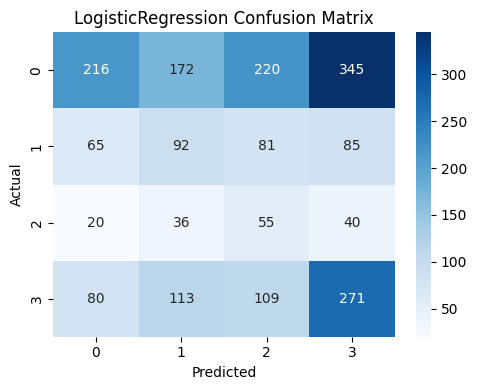

------------------------------------------------------------
RandomForest
Accuracy: 0.4435
                      precision    recall  f1-score   support

Assignment Completed       0.49      0.80      0.60       953
            Confused       0.18      0.03      0.06       323
             Gave Up       0.00      0.00      0.00       151
        Idea Drafted       0.32      0.20      0.25       573

            accuracy                           0.44      2000
           macro avg       0.24      0.26      0.23      2000
        weighted avg       0.35      0.44      0.37      2000



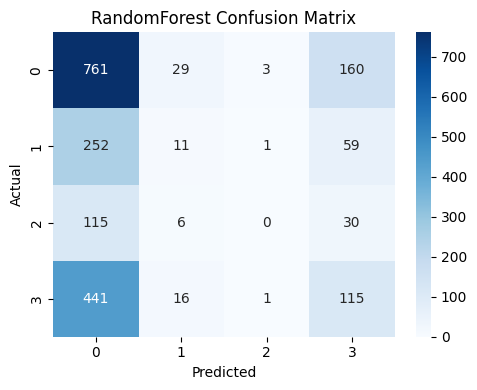

------------------------------------------------------------
KNN
Accuracy: 0.412
                      precision    recall  f1-score   support

Assignment Completed       0.48      0.70      0.57       953
            Confused       0.15      0.08      0.10       323
             Gave Up       0.16      0.04      0.06       151
        Idea Drafted       0.32      0.22      0.26       573

            accuracy                           0.41      2000
           macro avg       0.28      0.26      0.25      2000
        weighted avg       0.36      0.41      0.37      2000



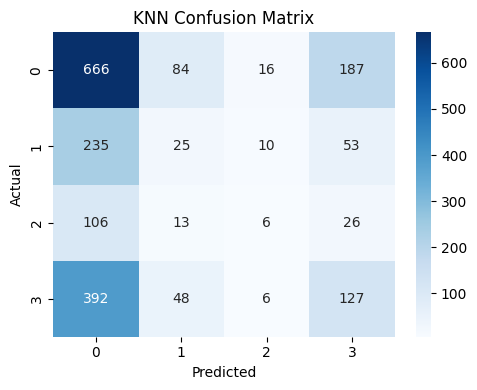

------------------------------------------------------------
SVM
Accuracy: 0.3005
                      precision    recall  f1-score   support

Assignment Completed       0.58      0.24      0.34       953
            Confused       0.20      0.27      0.23       323
             Gave Up       0.10      0.28      0.14       151
        Idea Drafted       0.33      0.42      0.37       573

            accuracy                           0.30      2000
           macro avg       0.30      0.30      0.27      2000
        weighted avg       0.41      0.30      0.32      2000



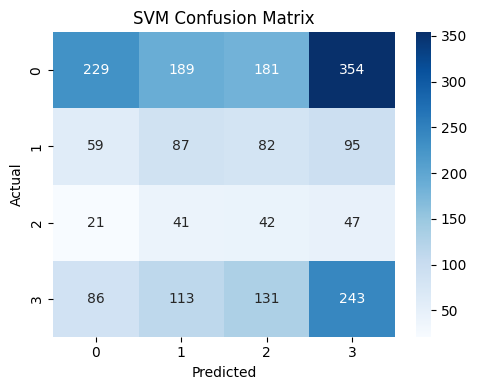

------------------------------------------------------------
NaiveBayes
Accuracy: 0.4595
                      precision    recall  f1-score   support

Assignment Completed       0.48      0.92      0.63       953
            Confused       0.42      0.02      0.05       323
             Gave Up       0.09      0.05      0.07       151
        Idea Drafted       0.33      0.05      0.08       573

            accuracy                           0.46      2000
           macro avg       0.33      0.26      0.21      2000
        weighted avg       0.40      0.46      0.34      2000



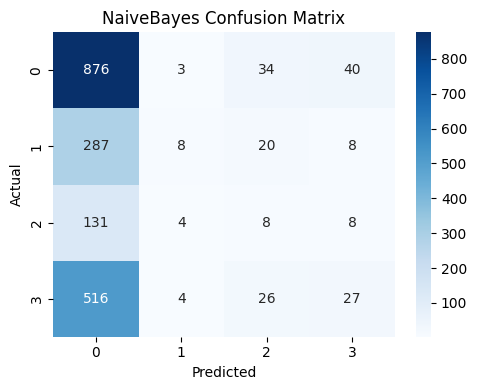

------------------------------------------------------------
AdaBoost
Accuracy: 0.474
                      precision    recall  f1-score   support

Assignment Completed       0.48      0.96      0.64       953
            Confused       0.00      0.00      0.00       323
             Gave Up       0.00      0.00      0.00       151
        Idea Drafted       0.30      0.06      0.09       573

            accuracy                           0.47      2000
           macro avg       0.20      0.25      0.18      2000
        weighted avg       0.32      0.47      0.33      2000



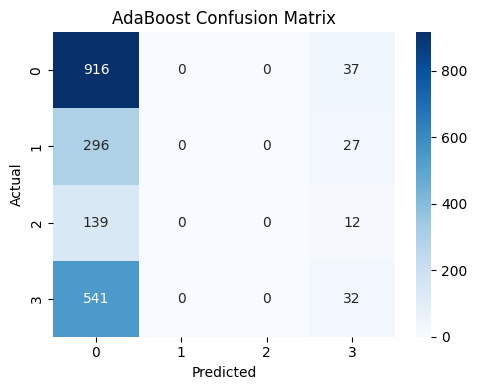

In [5]:
for name, model in models.items():
    print('------------------------------------------------------------')
    print(name)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print('Accuracy:', round(acc, 4))
    print(classification_report(y_test, preds, zero_division=0))

    cm = confusion_matrix(y_test, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

    joblib.dump(model, models_dir / f'finalOutcome_{name.lower()}.joblib')

    report = classification_report(y_test, preds, zero_division=0, output_dict=True)
    comparison_rows.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(report['macro avg']['precision'], 4),
        'Recall': round(report['macro avg']['recall'], 4),
        'F1-score': round(report['macro avg']['f1-score'], 4)
    })


In [6]:
comparison_df = pd.DataFrame(comparison_rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
comparison_df


,Model,Accuracy,Precision,Recall,F1-score
0,AdaBoost,0.4740,0.1951,0.2543,0.1845
1,NaiveBayes,0.4595,0.3303,0.2610,0.2075
2,RandomForest,0.4435,0.2446,0.2583,0.2265
3,KNN,0.4120,0.2760,0.2594,0.2485
4,LogisticRegression,0.3170,0.3184,0.3372,0.2912
5,SVM,0.3005,0.3018,0.3030,0.2711
